In [1]:
import torch
from torch.profiler import profile, ProfilerActivity, record_function
from kdv import *

# Model Initialization Testing

In [2]:
# See if model can be initialized
INIT_PARAMS = dict(
    num_solitons             = 1,
    n_hidden_layers          = 4, 
    n_neurons_per_layer      = 32, 
    activation               = nn.Tanh,
    seed                     = 72, 
    verbose                  = True,
)
model = KDV(INIT_PARAMS)

Using device: cuda


# Loss Function Testing

First step is testing if these functions both run and output the expected results

In [ ]:
from models_refactor.kdv.loss import *
from kdv_trainer import *

In [4]:
weights = {
    'w_ic': 10.7,
    'w_bc': 2.0
    #'w_pde': 20.0 #missing on purpose to test update works correctly
}

domain = setup_training_domain(1000, 100, 100, model.soliton_params)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#Test loss dict
losses = init_loss_list()
print(f'The loss dict: {losses}')

#Test loss weights
loss_weights = init_loss_weights(device, init_weights=None)
print(f'The loss wieghts as default: {loss_weights}')
loss_weights = init_loss_weights(device, weights)
print(f'The loss wieghts with dict: {loss_weights}')
print(f'Loss weights device: {loss_weights.device} \n')

#loss_comps = torch.tensor([0.3, 4.3, 1.0], device=loss_weights.device) #dummy var, check loss_components function with proper neural network
loss_comps = loss_components(model.neural_net, domain=domain)
total_loss = torch.dot(loss_weights, loss_comps)
#make sure that the dot operator works as intended
print(f'Total loss: {total_loss}')

The loss dict: {'total': [], 'initial': [], 'boundary': [], 'pde': []}
The loss wieghts as default: tensor([1., 1., 1.], device='cuda:0')
The loss wieghts with dict: tensor([10.7000,  2.0000,  1.0000], device='cuda:0')
Loss weights device: cuda:0 

Total loss: 0.9233183264732361


/home/jairdan/miniconda3/envs/soliton-pinns/lib/python3.14/site-packages/torch/autograd/graph.py:869: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:335.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


# Train Function Testing

In [15]:
#See if model can be trained
TRAIN_PARAMS = dict(
    adam_epochs              = 1000,
    lbfgs_epochs             = 1200,
    verbose_step             = 100,
    n_collocation            = 50000, 
    n_initial                = 30000,  
    n_boundary               = 10000,    
    adam_lr                  = 1e-3,   
    lbfgs_lr                 = 1.0,    
    lbfgs_history_size       = 100,  
    lbfgs_version            = 'test',
    adaptive_sampling        = True,
    logging                  = True
)

TRAIN_WEIGHTS = dict(
    w_ic                     = 5.0,    
    w_bc                     = 1.0,    
    w_pde                    = 15.0,
)

training_stats = model.train(TRAIN_PARAMS, TRAIN_WEIGHTS)

Weighted losses [start]: IC=1.444e-08 | BC=1.401e-08 | PDE=2.555e-07
Starting Adam optimization...
[gpu mem] train start               alloc   733.2 MB  reserved   818.0 MB  peak   733.2 MB
Adam - Epoch 0/1000, Total Loss: 2.839124e-07
Adam - Epoch 100/1000, Total Loss: 1.197635e-05
Adam - Epoch 200/1000, Total Loss: 2.979132e-06
Adam - Epoch 300/1000, Total Loss: 1.546040e-06
Adam - Epoch 400/1000, Total Loss: 1.079922e-06
Adam - Epoch 500/1000, Total Loss: 8.479655e-07
Adam - Epoch 600/1000, Total Loss: 7.025108e-07
Adam - Epoch 700/1000, Total Loss: 1.392716e-05
Adam - Epoch 800/1000, Total Loss: 8.344017e-07
Adam - Epoch 900/1000, Total Loss: 6.528742e-07
Adam - Epoch 999/1000, Total Loss: 5.512649e-07
[gpu mem] after Adam                alloc    34.6 MB  reserved  1580.0 MB  peak  1446.9 MB
Performing adaptive sampling...
cuda:0
cuda:0 | torch.Size([499849, 1])
cuda:0 | torch.Size([499849, 1])
Collocation points from 50000 -> 100000

Starting L-BFGS optimization...
L-BFGS - Iterat

# Testing Function Testing

In [16]:
model.test(1000, 1000, 'absolute-normalized')

absolute-normalized error metrics:
Mean: 2.026145e-03
Maximum: 3.810989e-02


ErrorStats(mae=0.002026145113632083, max_error=0.03810988739132881, error=tensor([[0.0001, 0.0001, 0.0001,  ..., 0.0003, 0.0003, 0.0003],
        [0.0001, 0.0001, 0.0001,  ..., 0.0003, 0.0003, 0.0004],
        [0.0001, 0.0001, 0.0001,  ..., 0.0004, 0.0004, 0.0004],
        ...,
        [0.0003, 0.0003, 0.0003,  ..., 0.0006, 0.0006, 0.0006],
        [0.0003, 0.0003, 0.0003,  ..., 0.0006, 0.0006, 0.0006],
        [0.0003, 0.0003, 0.0003,  ..., 0.0006, 0.0006, 0.0006]]))

# Visualizer Function Testing

In [17]:
import matplotlib.pyplot as plt

Losses

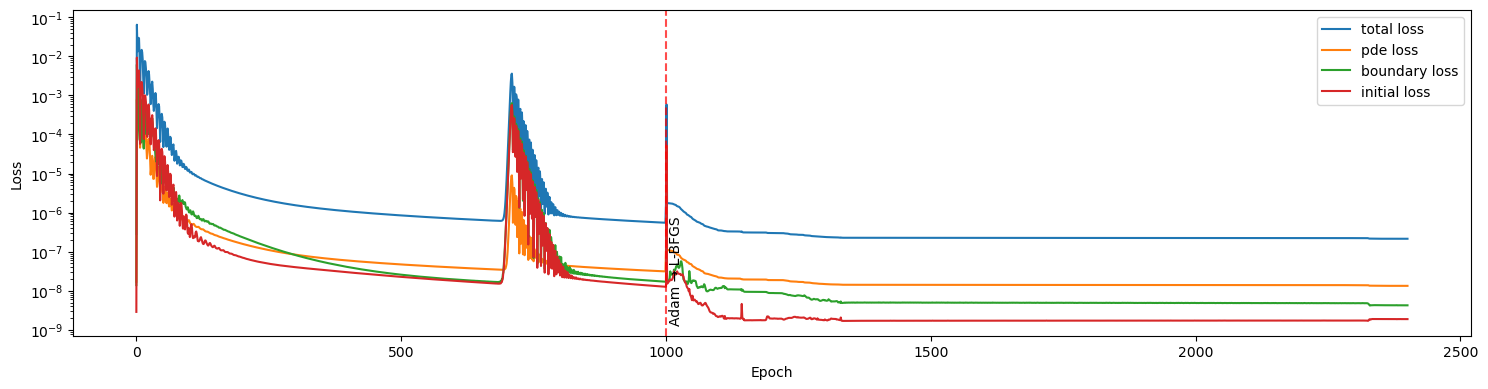

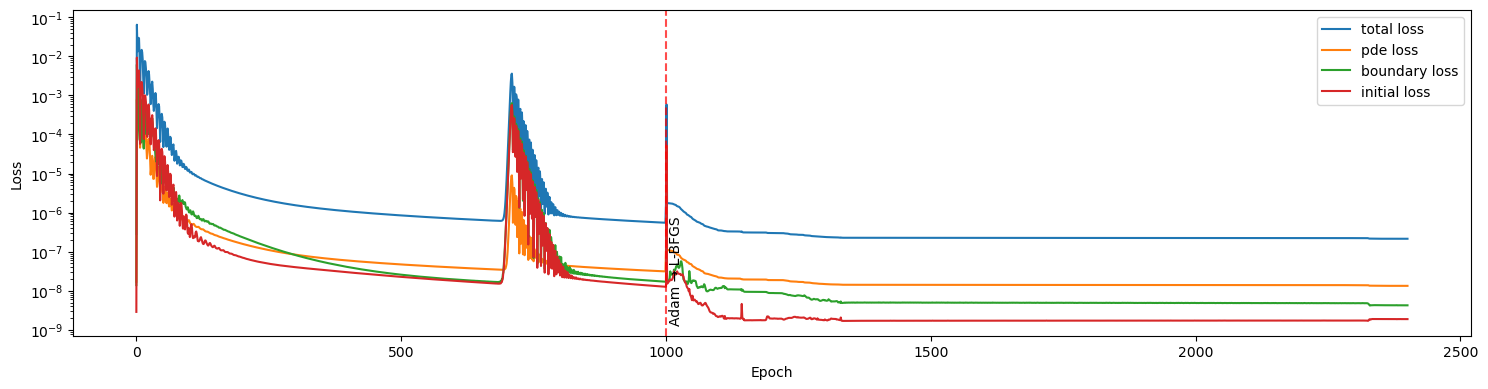

In [18]:
model.plot_losses(training_stats[0])

Profiles

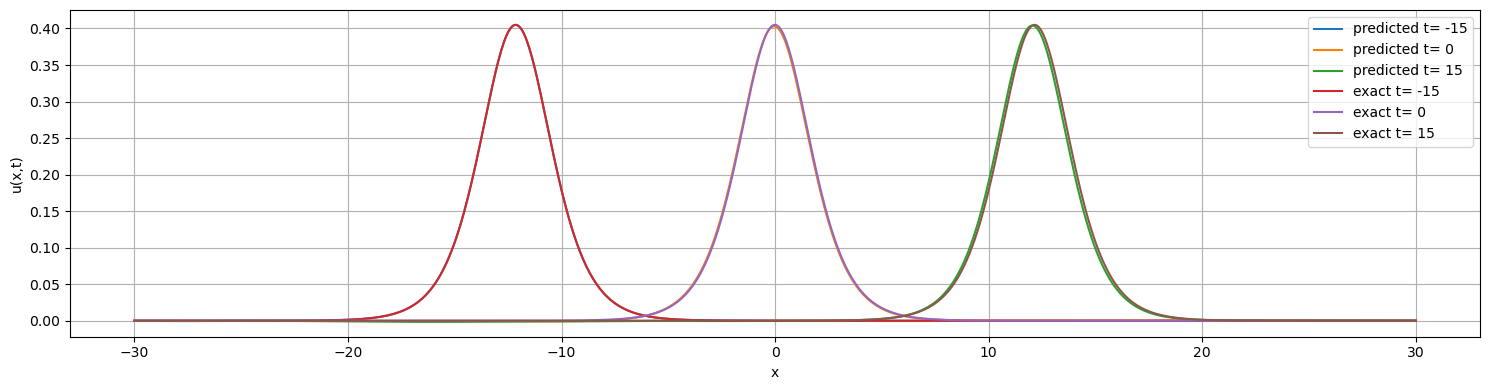

In [19]:
plot = model.plot_profiles([-15, 0, 15], ('predicted', 'exact'))

Spacetime

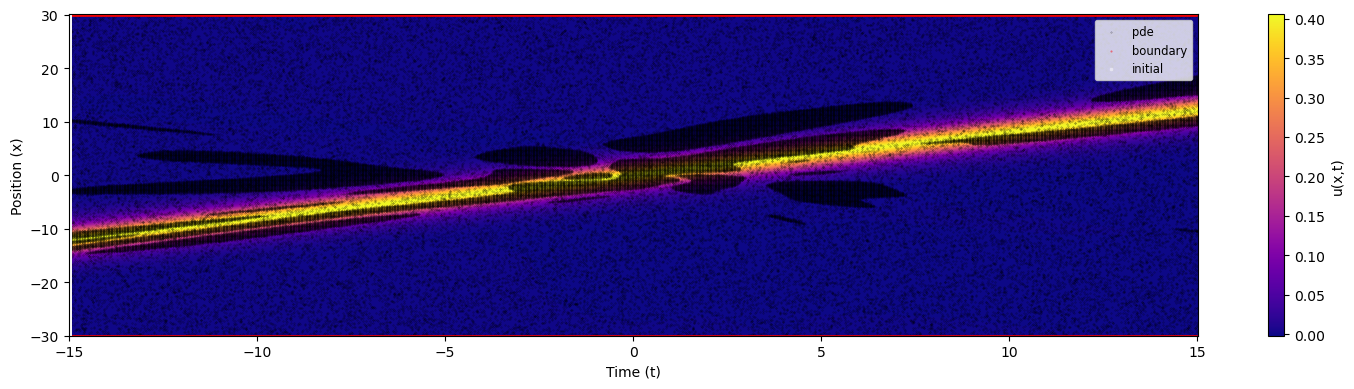

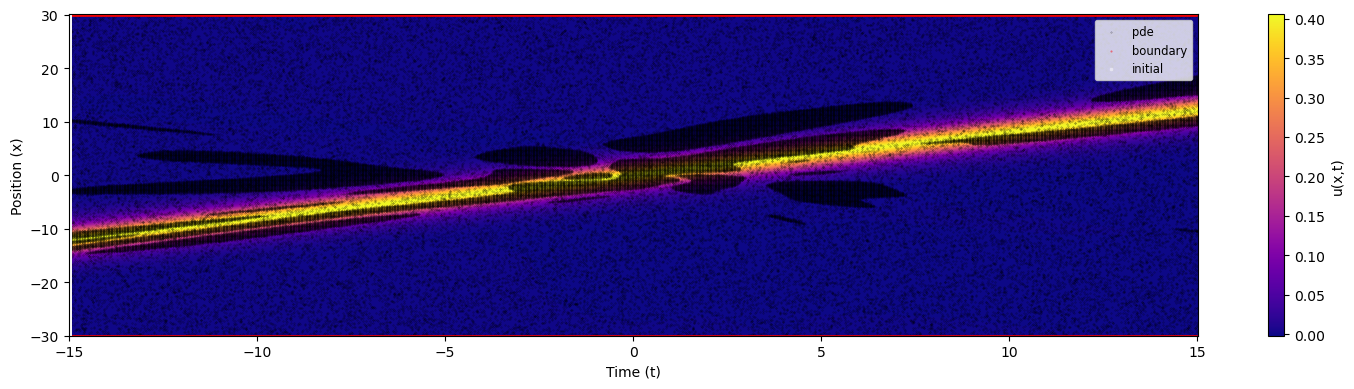

In [13]:
from kdv_trainer import setup_training_domain

training_domain = setup_training_domain(50000, 30000, 10000, model.soliton_params)
model.plot_spacetime(scatter_which=('pde', 'boundary', 'initial'), training_domain=training_stats[1])

Error Heatmap

absolute-normalized error metrics:
Mean: 2.026145e-03
Maximum: 3.810989e-02


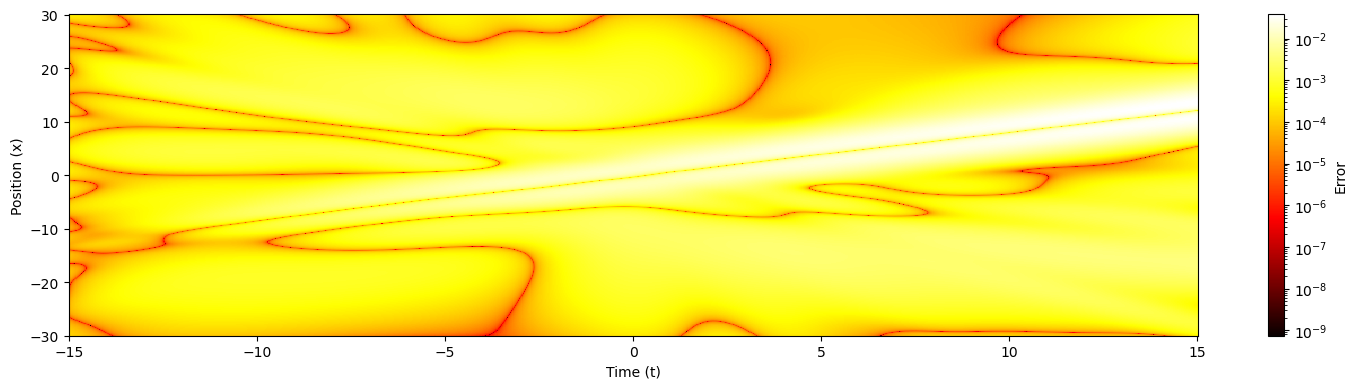

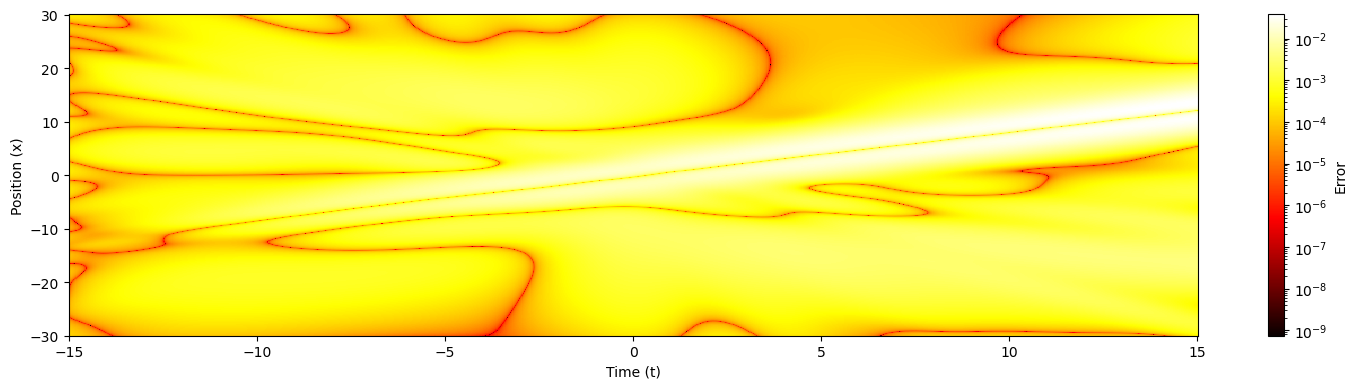

In [20]:
model.plot_heatmap()

# Function Profiling

In [ ]:
"""
import torch
from torch.profiler import profile, ProfilerActivity, record_function
from kdv import *

TRAIN_PARAMS = dict(
    adam_epochs              = 1000,
    verbose_step             = 100,
    n_collocation            = 50000, 
    n_initial                = 30000,  
    n_boundary               = 10000,    
    adam_lr                  = 1e-3,   
    lbfgs_lr                 = 1.0,    
    lbfgs_history_size       = 100,  
    lbfgs_version            = 'old',
    adaptive_sampling        = False,   
)

TRAIN_WEIGHTS = dict(
    w_ic                     = 5.0,    
    w_bc                     = 1.0,    
    w_pde                    = 15.0,
)

INIT_PARAMS = dict(
    num_solitons             = 1,
    n_hidden_layers          = 4, 
    n_neurons_per_layer      = 32, 
    activation               = nn.Tanh,
    seed                     = 42, 
    verbose                  = True,
)
"""

In [ ]:
"""
model = KDV(INIT_PARAMS)

def run():
    #add the sequence of loss function calls you want to run here
    return

with profile(
    activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA], 
    record_shapes=True, 
    profile_memory=True,
    with_modules=True,
    acc_events=True
) as p:
    run()
"""